In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, solvolysis_params, hydrogenolysis_params, hdo_params, etoac_purification, hexane_purification, rcf_oil_yield
from lignin_saf.settings.prices import prices,  _feedstock_price_dry_ton, kg_per_ton, h2_price
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank

## Global sensitivity analysis with Spearman

In [2]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840   # 2026 basis. CEPCI 
bst.settings.electricity_price = prices['electricity']

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF


combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)

h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

h2_hdo = bst.Stream()
h2_hdo.copy_like(F.HDO_H2_IN)

h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

# Shared H2 storage — sized from combined ETJ + HDO fresh H2 demand
h2_feed_mixer = bst.Mixer('H2_FEED_MIX', ins=(h2_rcf, h2_hdo, h2_etj))
shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_feed_mixer.outs[0])


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, nh3_splitter, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_feed_mixer, shared_h2_storage, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()

F.ETJ_H2_IN.price = prices['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = prices['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = prices['renewable_diesel']    # 1.888 USD/kg
#F.sulfuric_acid.price = prices['H2SO4']
#F.ammonia.price = prices['NH3']
F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 
#F.FGD_lime.price = prices['FOD_lime']
#F.boiler_chemicals.price = prices['Boiler_chemicals'] 


integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)

integrated_tea.labor_cost = labor
integrated_tea.operating_days = 330
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

# print(f'The MSP for SAF blend is  {mjsp} USD/gal')


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.22e-07 m2/s), and NPSH (3.89 ft); assuming centrigugal pump
  warn(f'{repr(

In [3]:
model = bst.Model(rcf_pure_mon_hdo_etoh_etj_system)

In [4]:

from chaospy import distributions as shape
param = model.parameter

Variation levels for diffent parameters 

In [5]:

var_50 = 0.5 # 50% variation in parameters - set for a few
var_20 = 0.2 # 20% variation in other parameters

### Overall (system-wide parameters) (7)

In [6]:
# Operating days — kind='isolated': only affects TEA time scaling, not mass/energy balance
dist = shape.Uniform(lower = 297 , upper = 363)
@param(name = 'Operating days',
    element = 'Overall',
    kind = 'isolated',
    units = 'days',
    baseline = integrated_tea.operating_days,
    distribution = dist)
def set_opertaing_days(i):
    integrated_tea.operating_days = i


# Poplar feedstock
dist = shape.Uniform(lower = 50 , upper = 100)
@param(name = 'Poplar feedstock price',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/DMT',
    baseline = _feedstock_price_dry_ton,
    distribution = dist)
def set_poplar_feedstock_price(i):
    # i is in USD/dry short ton; stream price must be USD/kg wet biomass
    F.Poplar_In.price = i / kg_per_ton / (1 + feed_parameters['moisture'])



# Labor cost
dist = shape.Uniform(lower = integrated_tea.labor_cost * (1-var_50) , upper = integrated_tea.labor_cost * (1+var_50) )
@param(name = 'Labor cost',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/yr',
    baseline = integrated_tea.labor_cost,
    distribution = dist)
def set_labor_cost(i): 
    integrated_tea.labor_cost = i


# Electricity price
dist = shape.Triangle(lower = 0.0826, midpoint = bst.settings.electricity_price, upper = 0.1798) 
@param(name = 'Electricity cost',
    element = 'Overall', 
    kind = 'isolated',
    units = 'USD/kWh',
    baseline = bst.settings.electricity_price, distribution = dist)
def set_electricity_price(i):
    bst.settings.electricity_price = i  

# Renewable napthha co-product revenue
dist = shape.Uniform(lower = 0.505 , upper = 0.77)
@param(name = 'RN co-product credit',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/kg',
    baseline =  F.ETJ_RN_OUT.price,
    distribution = dist)
def set_renewable_naptha_price(i): 
    F.ETJ_RN_OUT.price = i            


# Biodiesel co-product revenue
dist = shape.Uniform(lower = 0.63 , upper = 1.48)
@param(name = 'RD co-product credit',
       element = 'Overall',
       kind = 'isolated',
       units = 'USD/kg',
       baseline =  F.ETJ_RD_OUT.price,
       distribution = dist)
def set_bio_diesel_price(i): 
     F.ETJ_RD_OUT.price = i


# Hydrogen price
dist = shape.Triangle(lower = 2.74 , midpoint=3.70, upper = 11.53)
@param(name = 'Hydrogen price',
       element = 'Overall',
       kind = 'isolated',
       units = 'USD/kg',
       baseline =  h2_price,
       distribution = dist)
def set_hydrogen_price(i):
    F.ETJ_H2_IN.price = i
    F.RCF_H2_IN.price = i
    F.HDO_H2_IN.price = i


# Hydrogen storage time
dist = shape.Uniform(lower = 0.25 , upper = 3)
@param(name = 'Hydrogen storage period',
       element = 'Overall',
       kind = 'isolated',
       units = 'days',
       baseline =  F.H2_TK.storage_period,
       distribution = dist)
def set_h2_storage_period(i):
    F.H2_TK.storage_period = i
    F.H2_TK.simulate()   # re-runs _design()/_cost() so CAPEX updates for solve_price()


### Reductive Catalytic Fractionation parameters (13)

In [7]:
# Solvolysis pressure
dist = shape.Uniform(lower = solvolysis_params['P'],  upper = 83.3e5)
@param(name = 'Solvolysis reactor pressure',
    element = 'RCF', 
    kind = 'coupled',
    units = 'Pa',
    baseline = solvolysis_params['P'], distribution = dist)
def set_solvolysis_rxr_pressure(i):
    F.RCF_RXR1.P = i  



# Solvolysis reaction time
dist = shape.Triangle(lower = 1, midpoint = 3, upper = 4)
@param(name = 'Solvolysis reaction time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = solvolysis_params['tau_s'], distribution = dist)
def set_solvolysis_reaction_time(i):
    F.RCF_RXR1.tau = i      


# Solvolysis residence time
dist = shape.Triangle(lower = 9/60, midpoint = solvolysis_params['tau_s_res'], upper = 36/60) 
@param(name = 'Solvolysis residence time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = solvolysis_params['tau_s_res'], distribution = dist)
def set_solvolysis_residence_time(i):
    F.RCF_RXR1.tau_residence = i  


# Solvolysis cleaning time
dist = shape.Uniform(lower = 0.5, upper = 4) 
@param(name = 'Solvolysis cleaning time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.RCF_RXR1.tau_0, distribution = dist)
def set_solvolysis_cleaning_time(i):
    F.RCF_RXR1.tau_0 = i  


# Methanol price
dist = shape.Triangle(lower = 0.2648, midpoint = F.RCF_MEOH_IN.price, upper = 0.3972)
@param(name = 'Methanol cost',
    element = 'RCF', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.RCF_MEOH_IN.price, distribution = dist)
def set_methanol_price(i):
    F.RCF_MEOH_IN.price = i  

# Solvent losses in pulp
dist = shape.Uniform(lower=0.005, upper=0.1)
@param(name='RCF solvent losses',
       element='RCF',
       kind='coupled',
       units='-',
       baseline=solvolysis_params['solvent_losses'],
       distribution=dist)
def set_solvent_losses(i):
    solvolysis_params['solvent_losses'] = i


# RCF catalyst cost 
dist = shape.Uniform(lower = F.RCF_CAT_IN.price * (1-var_50) , upper = F.RCF_CAT_IN.price * (1+var_50) ) 
@param(name = 'RCF catalyst price',
    element = 'RCF', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.RCF_CAT_IN.price, distribution = dist)
def set_rcf_catalyst_price(i):
    F.RCF_CAT_IN.price = i      



# RCF catalyst lifetime 
dist = shape.Uniform(lower = 6, upper = 24) 
@param(name = 'RCF catalyst lifetime',
    element = 'RCF', 
    kind = 'isolated',
    units = 'months',
    baseline = solvolysis_params['cat_lifetime'], distribution = dist)
def set_rcf_catalyst_lifetime(i):
    solvolysis_params['cat_lifetime'] = i
    F.RCF_CAT_IN.imass['NiC'] = (
        solvolysis_params['cat_loading'] * (feed_parameters['flow'] * 1e3 / 24) * solvolysis_params['tau_h']
    ) / (i * 30 * 24)   # [kg/hr]


# RCF catalyst loading 
dist = shape.Uniform(lower = solvolysis_params['cat_loading'] * (1-var_50) , upper = solvolysis_params['cat_loading'] * (1+var_50) ) 
@param(name = 'RCF catalyst loading',
    element = 'RCF', 
    kind = 'isolated',
    units = 'kg/kg-biomass',
    baseline = solvolysis_params['cat_loading'], distribution = dist)
def set_rcf_catalyst_loading(i):
    solvolysis_params['cat_loading'] = i 
    F.RCF_CAT_IN.imass['NiC'] = (
        i * (feed_parameters['flow'] * 1e3 / 24) * solvolysis_params['tau_h']
    ) / (solvolysis_params['cat_lifetime'] * 30 * 24)   # [kg/hr]

# Cellulose retention
dist = shape.Triangle(lower=0.8, midpoint = solvolysis_params['Cellulose_retention'], upper=1.0)
@param(name='Cellulose retention',
       element='RCF',
       kind='coupled',
       units='%',
       baseline=solvolysis_params['Cellulose_retention'],
       distribution=dist)
def set_cellulose_retention(i):
    solvolysis_params['Cellulose_retention'] = i


# Xylose retention
dist = shape.Triangle(lower=0.2, midpoint = solvolysis_params['Xylose_retention'], upper=1.0)
@param(name='Xylose retention',
       element='RCF',
       kind='coupled',
       units='%',
       baseline=solvolysis_params['Xylose_retention'],
       distribution=dist)
def set_xylose_retention(i):
    solvolysis_params['Xylose_retention'] = i


# Delignification
dist = shape.Triangle(lower = 0.4 , midpoint = solvolysis_params['Delignification'], upper = 0.9)
@param(name = 'Delignfication',
       element = 'RCF',
       kind = 'coupled',
       units = '%',
       baseline = solvolysis_params['Delignification'], distribution = dist)
def set_delignfication(i):
    solvolysis_params['Delignification'] = i
    F.RCF_RXR1.reaction_1.X = i   


# Condensation extent
dist = shape.Triangle(lower = 0.001 , midpoint = hydrogenolysis_params['condensation_extent'], upper = 0.709)
@param(name = 'Condensation extent',
       element = 'RCF',
       kind = 'coupled',
       units = '%',
       baseline = hydrogenolysis_params['condensation_extent'], distribution = dist)
def set_condensation_extent(i):
    _X_scale = 1.0 - 1e-6
    hydrogenolysis_params['condensation_extent'] = i
    # X values are baked into the ParallelReaction at create_rcf_system() time; must update directly.
    # Reactions 0 & 1: Propylguaiacol/Propylsyringol (monomers that escaped condensation).
    # Reactions 4 & 5: S_Oligomer/G_Oligomer (baseline oligomers + condensed monomer fraction).
    F.RCF_RXR2.reaction[0].X = _X_scale * rcf_oil_yield['Monomers'] * 0.5 * (1 - i)
    F.RCF_RXR2.reaction[1].X = _X_scale * rcf_oil_yield['Monomers'] * 0.5 * (1 - i)
    F.RCF_RXR2.reaction[4].X = _X_scale * (rcf_oil_yield['Oligomers'] * 0.5 + rcf_oil_yield['Monomers'] * 0.5 * i)
    F.RCF_RXR2.reaction[5].X = _X_scale * (rcf_oil_yield['Oligomers'] * 0.5 + rcf_oil_yield['Monomers'] * 0.5 * i)


#### Hydrodeoxygenation parameters (5)

In [8]:
# HDO Reaction time 
dist = shape.Triangle(lower = 2, midpoint = 5, upper = 8)
@param(name = 'HDO reaction time',
    element = 'HDO', 
    kind = 'coupled',
    units = 'hr',
    baseline = hdo_params['tau'], distribution = dist)
def set_hdo_reaction_time(i):
    F.HDO_RXR1.tau = i  

# Solvent loading
dist = shape.Triangle(lower=0.01, midpoint = hdo_params['solvent_req'], upper=0.07)
@param(name='HDO solvent loading',
       element='HDO',
       kind='coupled',
       units='m3/kg monomer',
       baseline=hdo_params['solvent_req'],
       distribution=dist)
def set_hdo_solvent_req(i):
    hdo_params['solvent_req'] = i    

# Catalyst loading
dist = shape.Triangle(lower=hdo_params['catalyst_req'] * (1-var_50), midpoint = hdo_params['catalyst_req'], upper=hdo_params['catalyst_req'] * (1+var_50))
@param(name='HDO catalyst loading',
       element='HDO',
       kind='coupled',
       units='kg/kg monomer',
       baseline=hdo_params['catalyst_req'],
       distribution=dist)
def set_hdo_catalyst_req(i):
    hdo_params['catalyst_req'] = i


# Catalyst lifetime
dist = shape.Uniform(lower = 1, upper = 12) 
@param(name = 'HDO catalyst lifetime',
    element = 'HDO', 
    kind = 'isolated',
    units = 'months',
    baseline = hdo_params['cat_lifetime'], distribution = dist)
def set_hdo_catalyst_lifetime(i):
    hdo_params['cat_lifetime'] = i   # was 'catalyst_lifetime' — wrong key, never updated the real value
    # kind='isolated': dodecane_flow spec never runs, so update the stream directly (same pattern as RCF catalyst lifetime)
    F.HDO_CAT_IN.imass['Ni2PSiO2'] = (
        hdo_params['catalyst_req'] * F.MON_MONOMERS_OUT.F_mass * hdo_params['tau']
    ) / (i * 30 * 24)


# Dodecane price
dist = shape.Uniform(lower = 0.1 ,upper = 0.9)
@param(name = 'Dodecane cost',
    element = 'HDO', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.HDO_DODECANE_IN.price, distribution = dist)
def set_dodecane_in(i):
    F.HDO_DODECANE_IN.price = i  



#### Enzymatic Hydrolysis and Fermentation (8)

In [9]:
# Glucose to ethanol conversion
dist = shape.Triangle(lower = 0.8, midpoint = F.R303.cofermentation[0].X, upper = 0.95)
@param(name = 'Glucose to ethanol conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.cofermentation[0].X, distribution = dist)
def set_glucose_to_ethanol_conv(i):
    F.R303.cofermentation[0].X = i  

# Glucan to glucose conversion 
dist = shape.Triangle(lower = 0.8, midpoint = F.R303.saccharification[2].X,  upper = 0.9)
@param(name = 'Glucan to glucose conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.saccharification[2].X, distribution = dist)
def set_glucan_to_glucose_conv(i):
    F.R303.saccharification[2].X = i  


# Saccharification residence time
dist = shape.Triangle(lower = 60 * (1-var_20), midpoint = F.R303.tau_saccharification, upper = 60 * (1+var_20))
@param(name = 'Saccharification residence time',
    element = 'EHF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.R303.tau_saccharification, distribution = dist)
def set_saccharification_tau(i):
    F.R303.tau_saccharification = i  

# Cofermentation residence time
dist = shape.Triangle(lower = 36 * (1-var_20),  midpoint = F.R303.tau_cofermentation, upper = 36 * (1+var_20))
@param(name = 'Cofermentation residence time',
    element = 'EHF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.R303.tau_cofermentation, distribution = dist)
def set_cofermentation_tau(i):
    F.R303.tau_cofermentation = i  


# Xylose to ethanol conversion
dist = shape.Triangle(lower = 0.8, midpoint =  F.R303.cofermentation[4].X, upper = 0.9)
@param(name = 'Xylose to ethanol conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.cofermentation[4].X, distribution = dist)
def set_xylose_to_ethanol_conv(i):
    F.R303.cofermentation[4].X = i      

# Xylan to xylose conversion
dist = shape.Triangle(lower=0.8, midpoint = F.unit.R301.reactions[0].X , upper=0.9)
@param(name='Xylan to xylose conversion',
       element='Cellulosic ethanol',
       kind='coupled',
       units='-',
       baseline=F.unit.R301.reactions[0].X,
       distribution=dist)
def set_xylan_to_xylose_conversion(i):
    F.unit.R301.reactions[0].X = i



# Cellulase enzyme loading
dist = shape.Triangle(lower = 0.01, midpoint = F.M301.enzyme_loading, upper = 0.05)
@param(name = 'Cellulase enzyme loading',
    element = 'EHF', 
    kind = 'coupled',
    units = 'wt%',
    baseline = F.M301.enzyme_loading, distribution = dist)
def set_enzyme_loading(i):
    F.M301.enzyme_loading = i  


# Cellulase price
dist = shape.Uniform(lower = F.M301.ins[1].price * (1-var_50), upper = F.M301.ins[1].price * (1+var_50))
@param(name = 'Cellulase price',
    element = 'EHF',
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.M301.ins[1].price, distribution = dist)
def set_cellulase_price(i):
    F.M301.ins[1].price = i


    


#### Oil purification (OP) & Monomer purification (MP) (4)

In [10]:
# Etyl acetate solvent to crude RCF oil ratio
dist = shape.Uniform(lower=etoac_purification['solvent_to_crude_ratio'] * (1 - var_20),
                     upper=etoac_purification['solvent_to_crude_ratio'] * (1 + var_20))
@param(name='EtOAc solvent to crude ratio',
       element='OP',
       kind='coupled',
       units='L/kg',
       baseline=etoac_purification['solvent_to_crude_ratio'],
       distribution=dist)
def set_etoac_solvent_to_crude_ratio(i):
    etoac_purification['solvent_to_crude_ratio'] = i


# Ethyl acetate price
dist = shape.Uniform(lower = F.EthylAcetate_in.price * (1-var_50), upper = F.EthylAcetate_in.price * (1+var_50))
@param(name = 'Ethyl acetate price',
    element = 'OP', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.EthylAcetate_in.price, distribution = dist)
def set_ethyl_acetate_price(i):
    F.EthylAcetate_in.price = i  


# Hexane solvent to pure RCF oil ratio
dist = shape.Uniform(lower=1, upper = 5)
@param(name='Hexane solvent to pure oil ratio',
       element='MP',
       kind='coupled',
       units='kg/kg',
       baseline=hexane_purification['solvent_to_oil_ratio'],
       distribution=dist)
def set_hexane_to_pure_rcf_oil_ratio(i):
    hexane_purification['solvent_to_oil_ratio'] = i

# Hexane price
dist = shape.Triangle(lower = F.Hexane_In.price * (1-var_50), midpoint = F.Hexane_In.price, upper = F.Hexane_In.price * (1+var_50))
@param(name = 'Hexane price',
    element = 'MP', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.Hexane_In.price, distribution = dist)
def set_hexane_price(i):
    F.Hexane_In.price = i  

In [11]:
metric = model.metric
@metric(name='Minimum Jet Selling Price', element='TEA', units='USD/gal')
def get_msp():
    msp = (integrated_tea.solve_price(F.TOTAL_SAF) * F.TOTAL_SAF.rho) / 264.172
    return msp


In [12]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
import numpy as np
np.random.seed(3190)
samples = model.sample(N=3000, rule = 'L')  # Change this to 3000 later
model.load_samples(samples)

In [ ]:
model.evaluate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (3.11e+03 hp), head (3.3e+03 ft), kinematic viscosity (6.34e-07 m2/s), and NPSH (3.73 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel weight (1.486e+06 lb) is out of bounds (4200 to 1e+06 lb) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (50.42 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\m

In [ ]:
df_rho, df_p = model.spearman_r()
print(df_rho["TEA", "Minimum jet selling price [USD/gal]"])

Element             Parameter                               
Overall             Operating days [days]                      NaN
                    Poplar feedstock price [USD/DMT]           NaN
                    Labor cost [USD/yr]                        NaN
                    Electricity cost [USD/kWh]                 NaN
                    RN co-product credit [USD/kg]              NaN
                    RD co-product credit [USD/kg]              NaN
                    Hydrogen price [USD/kg]                    NaN
                    Hydrogen storage period [days]             NaN
RCF                 Solvolysis reactor pressure [Pa]           NaN
                    Solvolysis reaction time [hr]              NaN
                    Solvolysis residence time [hr]             NaN
                    Solvolysis cleaning time [hr]              NaN
                    Methanol cost [USD/kg]                     NaN
                    RCF solvent losses [-]                     NaN
 

In [ ]:
df_rho.to_excel('spearman_results_3000_runs_with_h2_triangular.xlsx')

In [ ]:
model.table

Element               Overall                                                                                                                ...  \
Feature Operating days [days] Poplar feedstock price [USD/DMT] Labor cost [USD/yr] Electricity cost [USD/kWh] RN co-product credit [USD/kg]  ...   
0                         341                             66.2            2.31e+07                     0.0914                         0.576  ...   
1                         329                             89.9            1.91e+07                     0.0977                         0.674  ...   
2                         333                             83.4            1.46e+07                     0.0951                         0.545  ...   
3                         305                             95.8            2.25e+07                      0.138                         0.509  ...   
4                         328                             70.1            1.21e+07                      0.124                         0.688  ...   
...                       ...                              ...                 ...                        ...                           ...  ...   
2995                      356                             83.2            1.83e+07                     0.0942                         0.737  ...   
2996                      319                             84.3             2.2e+07                      0.137                         0.547  ...   
2997                      325                             94.3            1.09e+07                      0.102                         0.545  ...   
2998                      346                             62.2            2.08e+07                     0.0832                          0.53  ...   
2999                      360                             75.7            1.75e+07                      0.106                         0.592  ...   

Element                                   OP                                                                    MP                        \
Feature Et oac solvent to crude ratio [L/kg] Ethyl acetate price [USD/kg] Hexane solvent to pure oil ratio [kg/kg] Hexane price [USD/kg]   
0                                      10.4                         0.938                                4.37                      0.791   
1                                      8.44                         0.939                                1.11                      0.614   
2                                      9.33                          1.06                                4.42                       1.07   
3                                      9.67                         0.397                                1.76                      0.757   
4                                      9.03                          1.14                                4.64                       1.03   
...                                     ...                           ...                                 ...                        ...   
2995                                     10                         0.483                                1.85                       1.49   
2996                                   10.1                         0.791                                2.91                      0.593   
2997                                   10.7                          0.59                                2.53                       1.61   
2998                                     10                         0.907                                3.16                      0.828   
2999                                   8.12                         0.969                                 1.5                       1.49   

Element                                 TEA  
Feature Minimum jet selling price [USD/gal]  
0                                      25.8  
1                                        30  
2                                      24.6  
3                       

In [ ]:
tabeuru = model.table.to_excel('spearman_gsa_37_samples_3000_with_h2_triangualr_runs.xlsx')

In [ ]:
df_rho["TEA", "Minimum jet selling price [USD/gal]"]


TEA
                                                       Minimum jet selling price [USD/gal]
Element            Parameter                                                              
Overall            Operating days [days]                                           -0.0994
                   Poplar feedstock price [USD/DMT]                                 0.0592
                   Labor cost [USD/yr]                                              0.0564
                   Electricity cost [USD/kWh]                                      -0.0209
                   RN co-product credit [USD/kg]                                    0.0109
                   RD co-product credit [USD/kg]                                   -0.0466
                   Hydrogen price [USD/kg]                                           0.115
                   Hydrogen storage period [days]                                   0.0609
RCF                Solvolysis reactor pressure [Pa]                                   0.02
                   Solvolysis reaction time [hr]                                     0.436
                   Solvolysis residence time [hr]                                   -0.464
                   Solvolysis cleaning time [hr]                                     0.146
                   Methanol cost [USD/kg]                                           0.0352
                   RCF solvent losses [-]                                            0.111
                   RCF catalyst price [USD/kg]                                      0.0107
                   RCF catalyst lifetime [months]                                   0.0214
                   RCF catalyst loading [kg/kg-biom...                            8.16e-05
                   Cellulose retention [%]                                          -0.224
                   Xylose retention [%]                                             -0.279
                   Delignfication [%]                                               -0.011
                   Condensation extent [%]                                           0.244
HDO                HDO reaction time [hr]                                           0.0702
                   HDO solvent loading [m3/kg monomer]                               0.244
                   HDO catalyst loading [kg/kg mono...                              0.0277
                   HDO catalyst lifetime [months]                                  -0.0699
                   Dodecane cost [USD/kg]                                           0.0924
EHF                Glucose to ethanol conv. [-]                                     -0.123
                   Glucan to glucose conv. [-]                                      -0.128
                   Saccharification residence time ...                             -0.0249
                   Cofermentation residence time [hr]                              0.00331
                   Xylose to ethanol conv. [-]                                      -0.014
Cellulosic ethanol Xylan to xylose conversion [-]                                  -0.0193
EHF                Cellulase enzyme loading [wt%]                                    0.231
                   Cellulase price [USD/kg]                                          0.147
OP                 Et oac solvent to crude ratio [L...                              0.0547
                   Ethyl acetate price [USD/kg]                                      0.143
MP                 Hexane solvent to pure oil ratio...                              0.0601
                   Hexane price [USD/kg]                                            0.0291

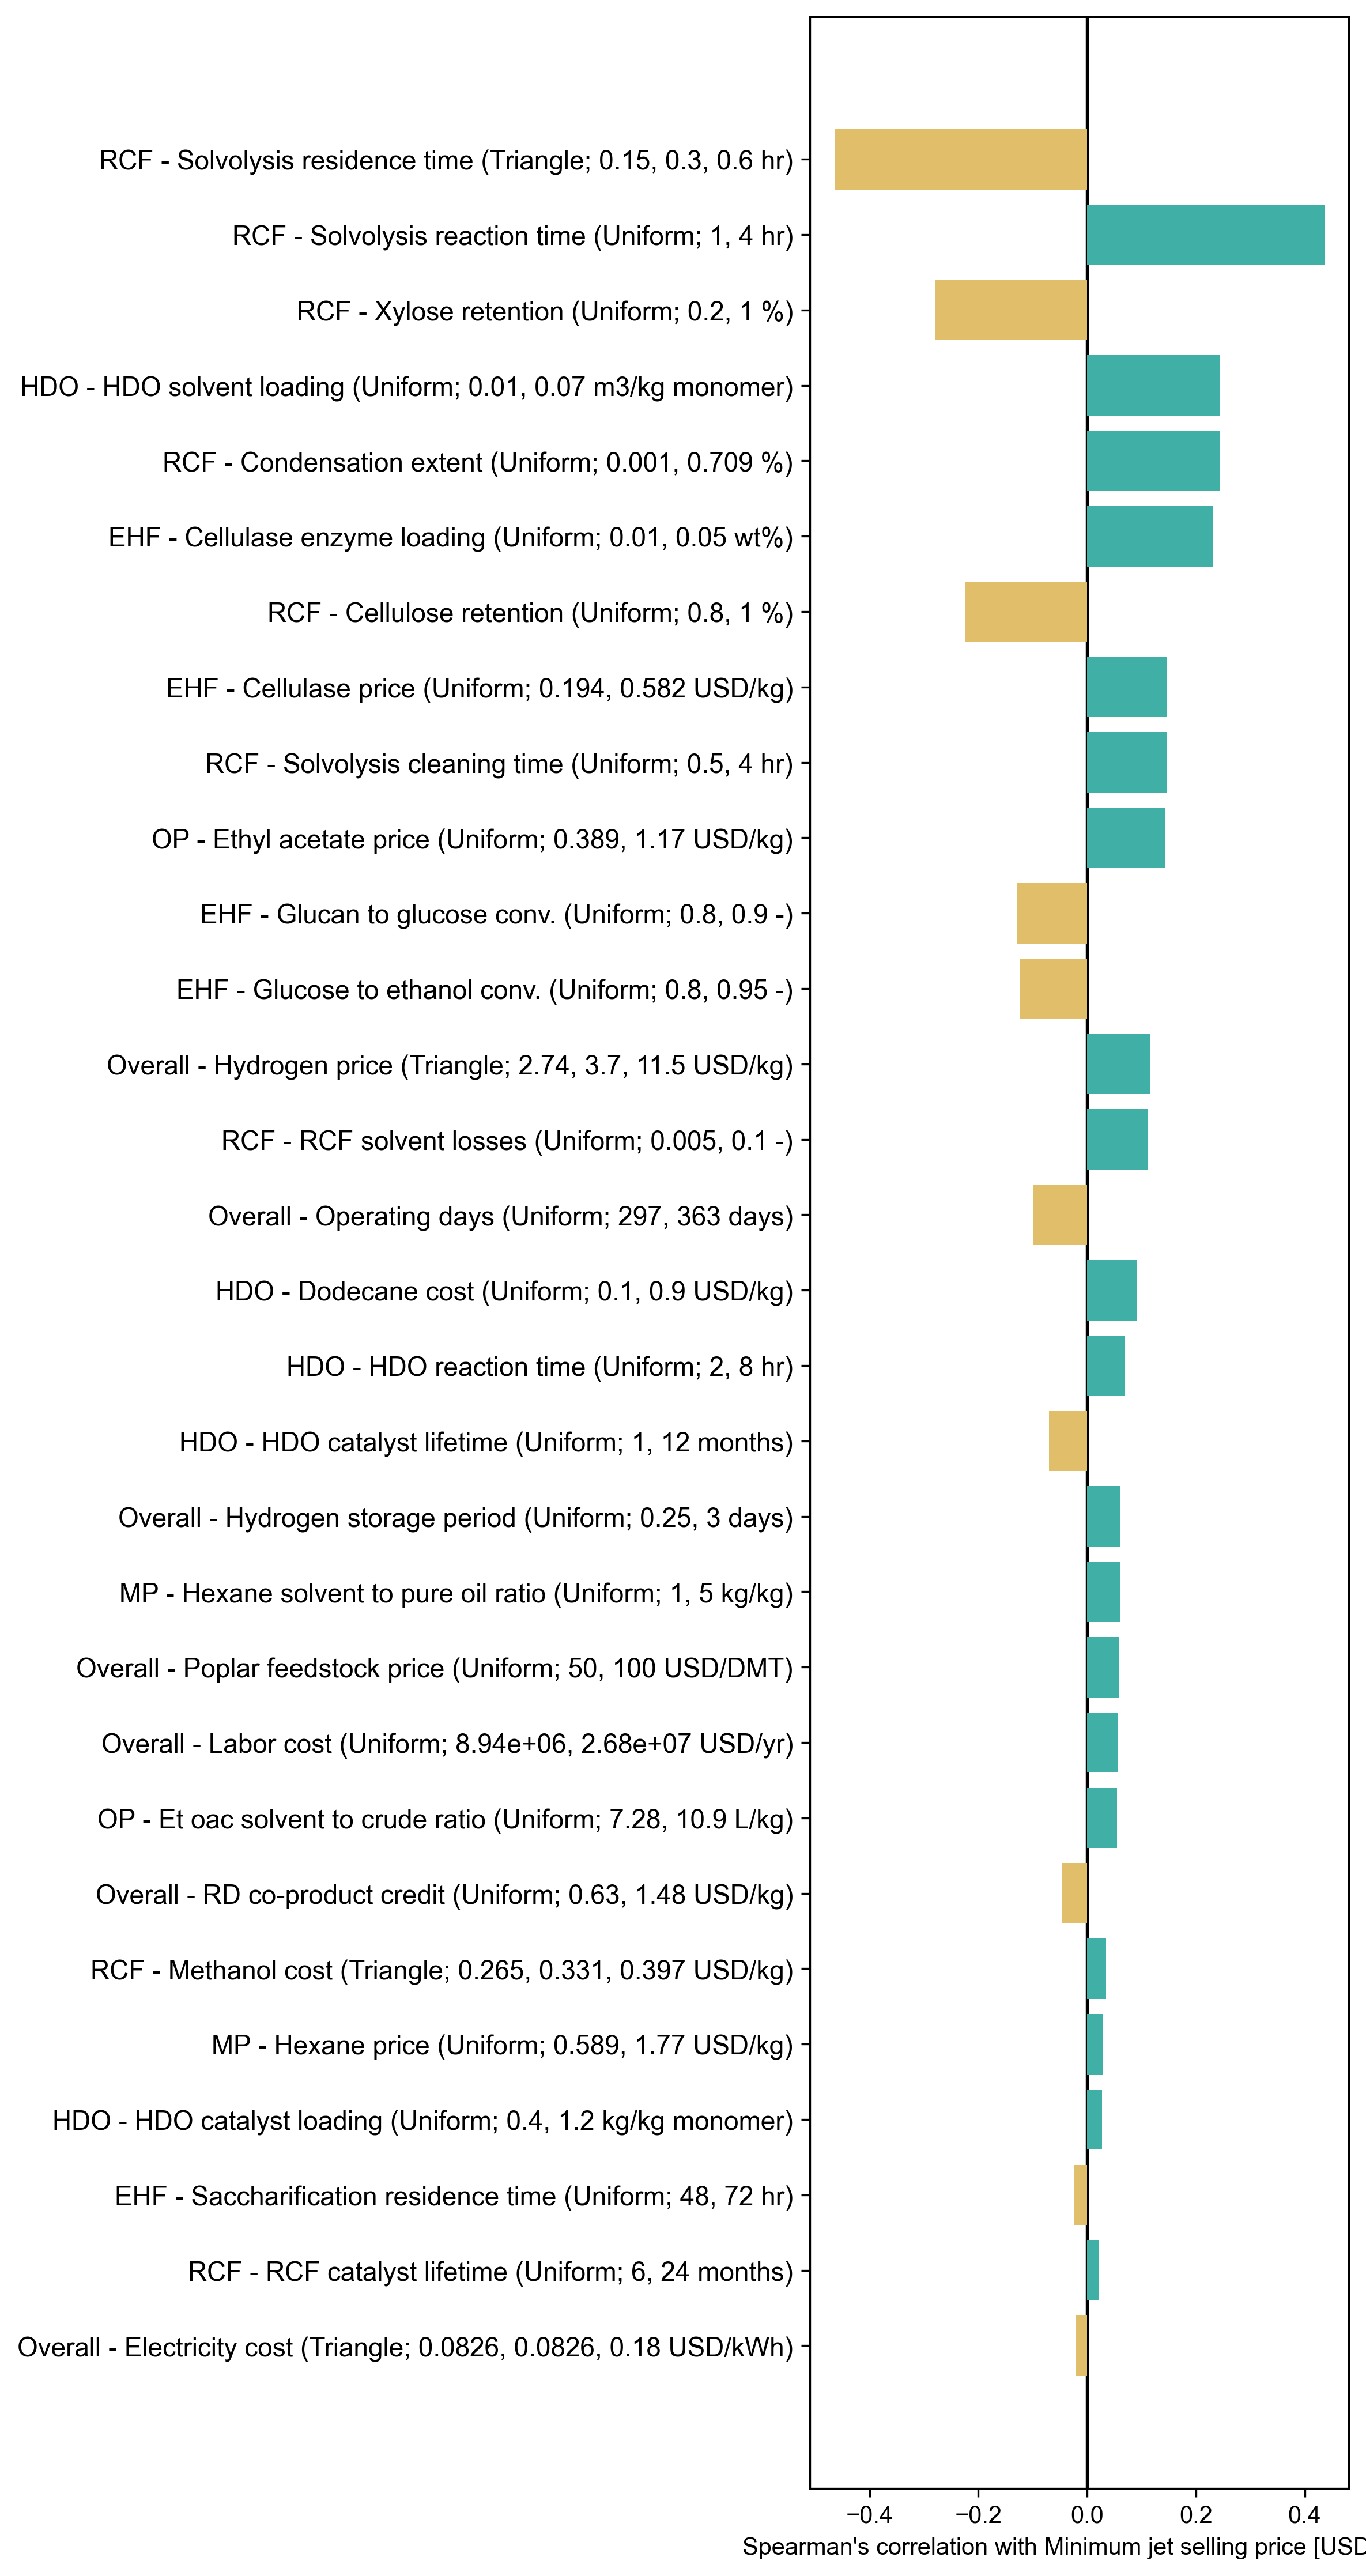

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.rc('font',family='Arial')

# Assume rho, labels, and model.parameters as before
N =  30 # Number of top parameters to plot
rho = df_rho["TEA", "Minimum jet selling price [USD/gal]"]
labels = [i.describe() for i in model.parameters]
values = rho.values

sorted_idx = np.argsort(np.abs(values))[::-1]
top_idx = sorted_idx[:N]
values_top = values[top_idx]
labels_top = np.array(labels)[top_idx]
colors = ['#40B0A6' if v > 0 else '#E1BE6A' for v in values_top]

fig, ax = plt.subplots(figsize=(8, max(5, N * 0.5)))
y_pos = np.arange(N)

# Add edgecolor and linewidth to the barh call
ax.barh(
    y_pos,
    values_top,
    color=colors,
    linewidth=1.5          # Border thickness
)


ax.axvline(x=0, color='k', linewidth=1.3, zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_top, fontsize=11)
ax.invert_yaxis()

ax.set_xlabel("Spearman's correlation with Minimum jet selling price [USD/gal]")
#ax.set_title(f"Top {N} Sensitivity Parameters (Spearman's rho)")
'''
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#B22222', edgecolor='black', label='Increase raises MJSP'),
    Patch(facecolor='#4682B4', edgecolor='black', label='Increase lowers MJSP'),
]
ax.legend(handles=legend_elements, loc='lower right')
'''
plt.savefig('gsa_2_10000_spearman_2.png', dpi = 300, bbox_inches = 'tight')
plt.tight_layout()
plt.show()


In [ ]:
values_top

array([-0.454,  0.438,  0.279, -0.273, -0.249,  0.218,  0.214,  0.204,
        0.17 ,  0.161,  0.142,  0.135,  0.133, -0.131, -0.115,  0.109,
        0.096, -0.09 ,  0.09 ,  0.081,  0.058,  0.048, -0.042,  0.041,
       -0.04 , -0.039,  0.037,  0.026,  0.023, -0.021])

In [ ]:
labels_top = pd.DataFrame()

In [ ]:
labels_top.to_excel('rank_spearman')

""


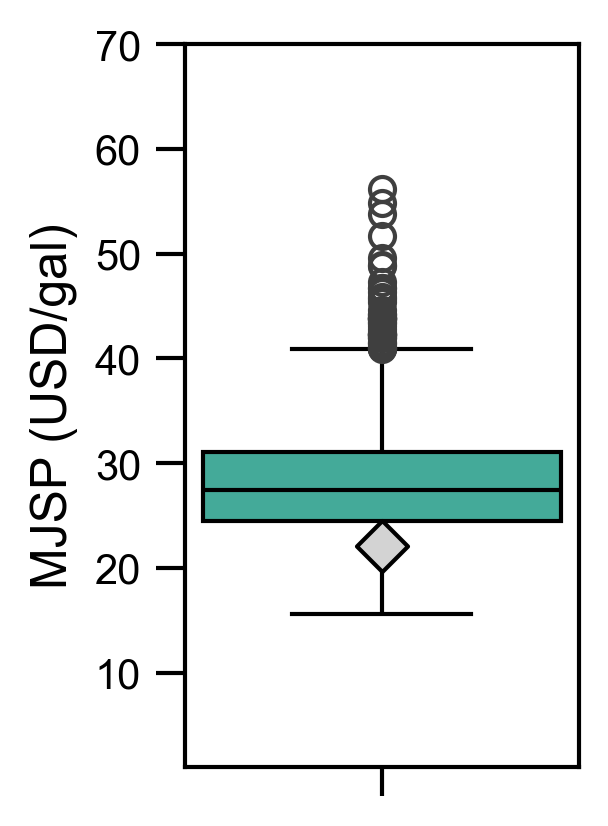

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font',family='Arial')

msp_values = model.table["TEA", "Minimum jet selling price [USD/gal]"]
msp_df = pd.DataFrame({'MSP ($/gal)': msp_values})
plt.figure(figsize=(1.6937007874, 3.12913386))  # Adjust figure size

# Way to fetch a color palette from seaborn
bugn = sns.color_palette('BuGn', n_colors=6)  # Get 6 shades of blue
light_bugn = bugn[2]
mid_bugn = bugn[4]
dark_bugn = bugn[5]
'''
# Create the violin plot with embedded box plot
sns.violinplot(
    data=msp_df,
    y="MSP ($/gal)",
    inner="box",
    color="#c6dbef",  # Violin body color (HEX)
    linewidth=0
)

'''

sns.boxplot(
    data=msp_df,
    y="MSP ($/gal)",
    width=0.20,
    boxprops={"facecolor": "#44AA99", "edgecolor": 'black', "linewidth": 1},
    medianprops={"color": "black", "linewidth": 1},
    whiskerprops={"color": "black", "linewidth": 1},
    capprops={"color": "black", "linewidth": 1}
)



# Add gray diamond marker at 8.6
ax = plt.gca()
ax.scatter(
    x=0, y=22.08,  # x=0 for single-category violin/box plot
    marker='D',  # Diamond marker
    s=75,       # Size of the marker
    facecolor='lightgray',
    edgecolor='black',
    linewidth=1,
    zorder=10
)


plt.tick_params(axis='both', which='major', labelsize=12, width=1.0, length=7)
# set the axis line width in pixels
ax = plt.gca()  # Get current axes
for axis in ['left', 'bottom', 'top', 'right']:
    ax.spines[axis].set_linewidth(1)
    ax.set_ylim(1, 70)
plt.yticks(fontsize = 10, color = 'black')


# Label the plot
plt.ylabel("MJSP (USD/gal)", fontsize=12, color = 'black')
#plt.title(f'Capacity: {round((saf_stream.F_vol*264.17*24*330)/1e6,1)} MM gal/yr', fontsize=16, color = 'black')
#plt.grid(True, 'major', 'y', linestyle="--", linewidth=1.2, alpha=0.5, color = 'gray')


# Add shaded area from 2.4 to 3 USD/gal
#ax.axhspan(2.4, 3.0, color='#88CCEE', alpha=0.5, zorder=0)

# Add shaded area from 4.4 
#ax.axhspan(4.6, 9.6, color='#DDCC77', alpha=0.5, zorder=0)

# Saving the plot
#plt.savefig("msp_violin_plot.png", dpi=300, bbox_inches="tight")  # PNG format (high quality)
# Show the plot

# plt.savefig("box plot.svg", bbox_inches="tight")
plt.show()

In [ ]:
msp_df.to_excel('msp_values')

,MSP ($/gal)
0,23.7
1,21.1
2,41.2
3,36.8
4,26.5
...,...
995,30.7
996,30.9
997,43.8
998,25
